# Test ABL with K-epsilon model

In [1]:
# Add any possible locations of amr-wind-frontend here
import sys, os
curdir = os.getcwd()
extradirs = ['../', './',
             os.path.dirname(curdir),
            ]
for x in extradirs: sys.path.insert(1, x)

import numpy as np
import matplotlib.pyplot as plt
import SANDwake3D_base as sdb
import SANDwake3D_keps as SANDwake3D

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import time
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
from mpl_toolkits.axes_grid1 import make_axes_locatable
#?solve_ivp

## Set mesh and BC's 

In [3]:
# Set up mesh and BL parameters
nu   = 1.5E-5 # m^2/s

# y-z mesh 
zmin = 5
zmax = 250
Nz   = int((zmax-zmin)/5+1)
zvec = np.linspace(zmin,zmax,Nz)

Ny=51
ymax = 125
yvec = np.linspace(-ymax,ymax,Ny)

# x grid
xvecplot = [0, 10]

In [4]:
ym, zm = np.meshgrid(yvec, zvec, indexing='ij')

dy   = np.mean(np.diff(yvec))
dz   = np.mean(np.diff(zvec))
print(f'dy = {dy}')
print(f'dz = {dz}')
print(ym.shape)

dy = 5.0
dz = 5.0
(51, 50)


In [5]:
# Set parameters
params = {
    'rho' : 1.225,
    'cp'  : 1005,
    'g'   : 9.81,
    'nu'  : nu,
    'Cmu' : 5.48**(-2),
    'C1eps' : 1.76,
    'C2eps' : 1.92,
    'C3eps' : 0.033,
    'sigmak' : 1.0,
    'sigmaeps' : 1.3,
    'sigmaT':1.0,
    'dtau':1.0,
    
    'ustar' : 0.4, #0.4, #0.575652,
    'qw': 0.0,
    'L' : float('inf'),
    'kappa' : 0.42,
    'z0' : 0.05,

    'zlo':zmin,
    'Tw':300,
    
    # Extra mesh variables needed for turbine forcing
    'ym':ym,
    'zm':zm,
    'turbforcing':{'turbx':0.0,     # Turbine x location
                   'turby':0.0,     # Turbine y location
                   'zhh':80.0,      # Turbine hub-height
                   'turbD':100.0,   # Turbine diameter
                   'Ct':0.8,
                   'Rdelta':2.0,
                   'Uinf':5.98,
                   'turbfunc':sdb.tanhADM,
                  }
}

# This parameter defines V(z) -- m/s per meter
veerpermeter = 0.0 #0.02

In [6]:
# Set up ABL profile
UABL = np.zeros(Nz)
for iz, z in enumerate(zvec):
    UABL[iz] = SANDwake3D.init_U_ABL(z,params)
    
# Set up veer profile
turbhh = params['turbforcing']['zhh']
turbR  = params['turbforcing']['turbD']*0.5
veerV = np.zeros(Nz)
for i, z in enumerate(zvec):
    veerV[i] = veerpermeter*(z-turbhh)
    
# Compute the wind direction
ztop = turbhh + turbR
zbot = turbhh - turbR
Utop, Ubot = np.interp(ztop, zvec, UABL), np.interp(zbot, zvec, UABL)
Vtop, Vbot = np.interp(ztop, zvec, veerV), np.interp(zbot, zvec, veerV)
Wdirtop = np.arctan2(Vtop, Utop)*180/np.pi
Wdirbot = np.arctan2(Vbot, Ubot)*180/np.pi

Uhh, Vhh = np.interp(turbhh, zvec, UABL), np.interp(turbhh, zvec, UABL)
alpha = np.log(Utop/Ubot)/np.log(ztop/zbot)
print('Uhh = ',Uhh)
print('alpha = ',alpha)
print('rotor veer = ',Wdirtop-Wdirbot)

Uhh =  7.0264370554551165
alpha =  0.1407479933169162
rotor veer =  0.0


In [7]:
Uinit  = np.zeros((Ny, Nz))
Vinit  = np.zeros((Ny, Nz))
Winit  = np.zeros((Ny, Nz))
Kinit  = np.zeros((Ny, Nz))
Tinit  = np.ones((Ny, Nz))*300
EPSinit= np.zeros((Ny, Nz))
pinit  = np.zeros((Ny, Nz))

for iz, z in enumerate(zvec):
    Uinit[:, iz] = UABL[iz] #SANDwake3D.init_U_ABL(z,ABLparam)
    Vinit[:, iz] = veerV[iz]
    Winit[:, iz] = 0.0
    #Kinit[:, iz]   = SANDwake3D.init_k_ABL(z,ABLparam) #*0.5 #0.2
    #EPSinit[:, iz] = 5.0E-3 #9.75E-4 #5.0E-4 #SANDwake3D.init_e_ABL(z,ABLparam)*0.1  #5.0E-4 is good
    EPSinit[:, iz] = SANDwake3D.init_e_ABL(z,params)
    #EPSinit[:, iz] = SANDwake3D.init_e_ABL(z,ABLparam)*0.50  #5.0E-4 is good

phiinit = {}
phiinit['u'] = Uinit
phiinit['v'] = Vinit
phiinit['w'] = Winit
phiinit['k'] = Kinit
phiinit['T'] = Tinit
phiinit['eps'] = EPSinit
phiinit['p'] = pinit

(0.0, 250.0)

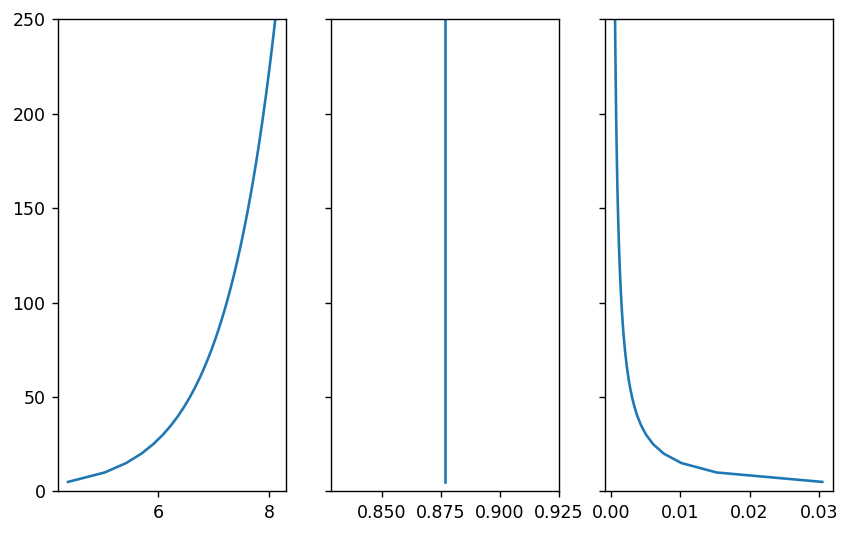

In [8]:
fig, axs = plt.subplots(1,3, sharey=True, dpi=125, figsize=(8,5))
axs[0].plot(Uinit[Ny//2,:], zvec)
axs[1].plot(Kinit[Ny//2,:], zvec)
axs[2].plot(EPSinit[Ny//2,:], zvec)
axs[0].set_ylim([0, zmax])

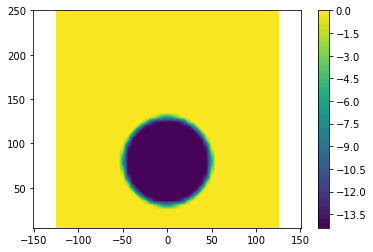

In [9]:
# Plot what the wake forcing field looks like
Uinf = sdb.rotorAvgUh(ym, zm, Uinit, Vinit, params['turbforcing']['turby'], params['turbforcing']['zhh'], 0.5*params['turbforcing']['turbD'])
wakeF = sdb.tanhADM(1.0, ym, zm,  5.98, params['turbforcing'])
plt.contourf(ym, zm, wakeF, levels=51)
plt.axis('equal')
plt.colorbar()

In [10]:
# Set boundary conditions
ubc = {}
ubc['ylo'] = {'type':'neumann', 'value':0.0}
ubc['yhi'] = {'type':'neumann', 'value':0.0}
ubc['zlo'] = {'type':'bcfunc', 'value':None, 'tag':'ZLO_WALLBC',  'func':SANDwake3D.MO_wallmodel}
              #'func':(lambda phi, aux, param: {'u':{'zlo':{'type':'dirichlet','value':Uinit[0,0]}}})}
#ubc['zlo'] = {'type':'dirichlet', 'value':Uinit[0,0]}
ubc['zhi'] = {'type':'dirichlet', 'value':Uinit[0,-1]}
#ubc['zhi'] = {'type':'neumann', 'value':0.0}

vbc = {}
vbc['ylo'] = {'type':'dirichlet', 'value':veerV}
#vbc['ylo'] = {'type':'bcfunc', 'value':None, 'tag':'MyYLO_VBC', 'func':(lambda phi, aux, param, debugout=False: {'v':{'ylo':{'type':'dirichlet','value':veerV}}})}
vbc['yhi'] = {'type':'dirichlet', 'value':0.0}
vbc['zlo'] = {'type':'dirichlet', 'value':0.0}
vbc['zhi'] = {'type':'dirichlet', 'value':0.0}

wbc = {}
wbc['ylo'] = {'type':'neumann', 'value':0.0}
wbc['yhi'] = {'type':'neumann', 'value':0.0}
wbc['zlo'] = {'type':'dirichlet', 'value':0.0}
wbc['zhi'] = {'type':'neumann', 'value':0.0}

kbc = {}
kbc['ylo'] = {'type':'neumann', 'value':0.0}
kbc['yhi'] = {'type':'neumann', 'value':0.0}
kbc['zlo'] = {'type':'bcfunc', 'value':None, 'tag':'ZLO_WALLBC',  'func':SANDwake3D.MO_wallmodel}
#kbc['zlo'] = {'type':'dirichlet', 'value':Kinit[0,0]}
kbc['zhi'] = {'type':'neumann', 'value':0.0}

epsbc = {}
epsbc['ylo'] = {'type':'neumann', 'value':0.0}
epsbc['yhi'] = {'type':'neumann', 'value':0.0}
epsbc['zlo'] = {'type':'bcfunc', 'value':None, 'tag':'ZLO_WALLBC',  'func':SANDwake3D.MO_wallmodel}
#epsbc['zlo'] = {'type':'dirichlet', 'value':EPSinit[0,0]}
epsbc['zhi'] = {'type':'neumann', 'value':0.0}

Tbc = {}
Tbc['ylo'] = {'type':'dirichlet', 'value':params['Tw']}
Tbc['yhi'] = {'type':'dirichlet', 'value':params['Tw']}
Tbc['zlo'] = {'type':'bcfunc', 'value':None, 'tag':'ZLO_WALLBC',  'func':SANDwake3D.MO_wallmodel}
#Tbc['zlo'] = {'type':'dirichlet', 'value':params['Tw']}
Tbc['zhi'] = {'type':'dirichlet', 'value':params['Tw']}

pbc = {}
pbc['ylo'] = {'type':'neumann', 'value':0.0}
pbc['yhi'] = {'type':'neumann', 'value':0.0}
pbc['zlo'] = {'type':'dirichlet', 'value':0.0}
pbc['zhi'] = {'type':'neumann', 'value':0.0}

allbc = {'u':ubc, 'v':vbc, 'w':wbc, 'k':kbc, 'eps':epsbc, 'T':Tbc, 'p':pbc}

In [11]:
xvecplot=[-100, 0, 100, 300, 400, 500] 
#xvecplot = [-50, 0, 50, 100]
dx  = 50 #25

#xvec = [0, 10, 20, 30, 40]
xvec = np.arange(xvecplot[0], xvecplot[-1]+1.0E-6, dx)
#xvec = [0, 10, 20]

#xvec = [0.0, 2.5, 5.0, 7.5, 10, 15, 20, 25, 30]
#xvec = np.arange(xvecplot[0], xvecplot[0]+dx+1.0E-6, dx)

#xvec = xvecplot
start_time = time.time()
phi = SANDwake3D.marchSystem(phiinit, xvec, dy, dz, params, allbc, SANDwake3D.kepsT_eqns, 
                             advanceSys=SANDwake3D.advanceSystemKEPS,
                             verbose=True, maxiter=100, tol=1.0E-4)
end_time = time.time()
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.4f} seconds")

x = -50.0 dx = 50.0
['u', 'w', 'k', 'eps', 'T', 'v', 'p']
[0] u: 5.2678e+00, w: 0.0000e+00, k: 1.9087e+00, eps: 9.1503e-02, T: 3.7400e-12, v: 0.0000e+00, p: 0.0000e+00
[1] u: 4.0214e+00, w: 0.0000e+00, k: 1.6587e+00, eps: 7.2550e-02, T: 5.6909e-12, v: 0.0000e+00, p: 2.8655e-05
[2] u: 2.8914e+00, w: 8.4008e-06, k: 1.3142e+00, eps: 5.6517e-02, T: 6.1975e-12, v: 1.4417e-06, p: 2.7225e-05
[3] u: 2.1682e+00, w: 7.9800e-06, k: 9.7094e-01, eps: 4.1308e-02, T: 5.9537e-12, v: 1.3713e-06, p: 1.6933e-05
[4] u: 1.5655e+00, w: 4.9767e-06, k: 7.1658e-01, eps: 3.0538e-02, T: 6.1564e-12, v: 8.4431e-07, p: 1.4718e-05
[5] u: 1.1613e+00, w: 4.3253e-06, k: 5.2311e-01, eps: 2.2272e-02, T: 4.9873e-12, v: 7.3412e-07, p: 9.4274e-06
[6] u: 8.4465e-01, w: 2.7707e-06, k: 3.8479e-01, eps: 1.6404e-02, T: 5.7662e-12, v: 4.7022e-07, p: 7.6009e-06
[7] u: 6.2379e-01, w: 2.2337e-06, k: 2.8172e-01, eps: 1.2004e-02, T: 5.3926e-12, v: 3.7916e-07, p: 5.1607e-06
[8] u: 4.5578e-01, w: 1.5167e-06, k: 2.0711e-01, eps: 8.8300e-

(5.0, 250.0)

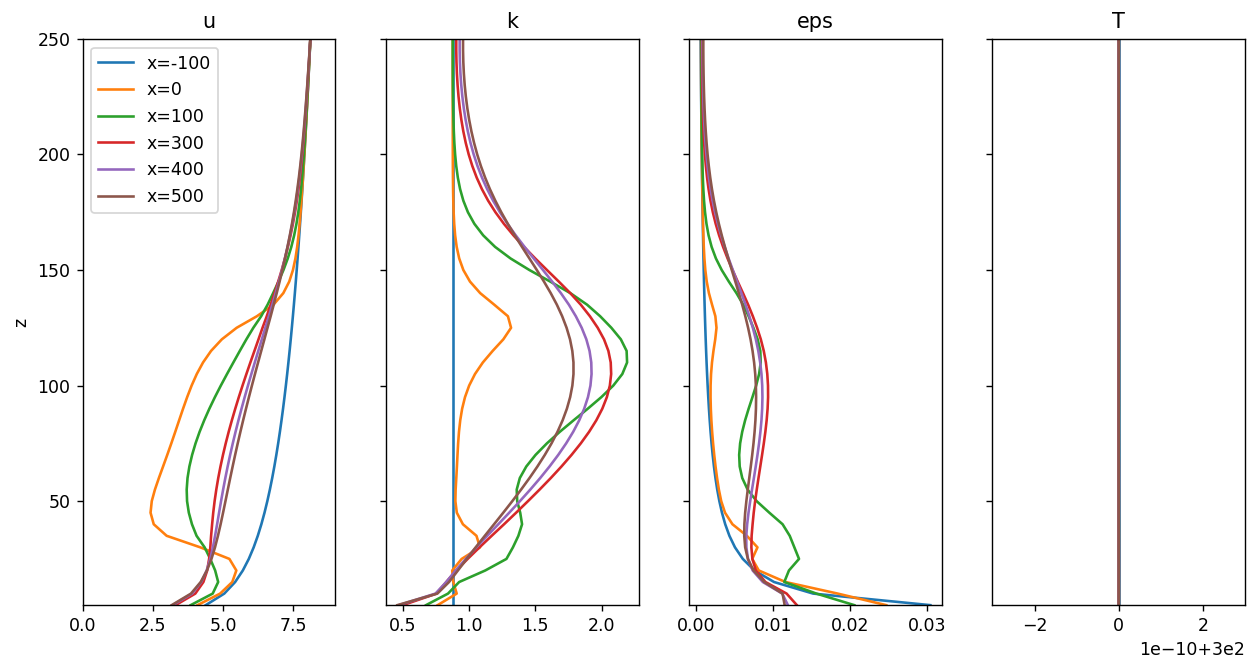

In [12]:
plotvars=['u', 'k', 'eps', 'T']
islice = Ny//2
find_nearest = lambda a, a0: np.abs(np.array(a) - a0).argmin()

#xvecplot=[0, 50]

fig, axs = plt.subplots(1,len(plotvars),figsize=(12,6), dpi=125, sharey=True)
for iv, v in enumerate(plotvars):
    for x in xvecplot:
        ixRANS = find_nearest(xvec, x)
        axs[iv].plot(phi[v][ixRANS,islice,:], zvec, label='x=%.0f'%x)
    axs[iv].set_title(v)
    
axs[0].legend()
axs[0].set_xlim([0, 9])
axs[0].set_ylabel('z')
axs[0].set_ylim([zmin, zmax])

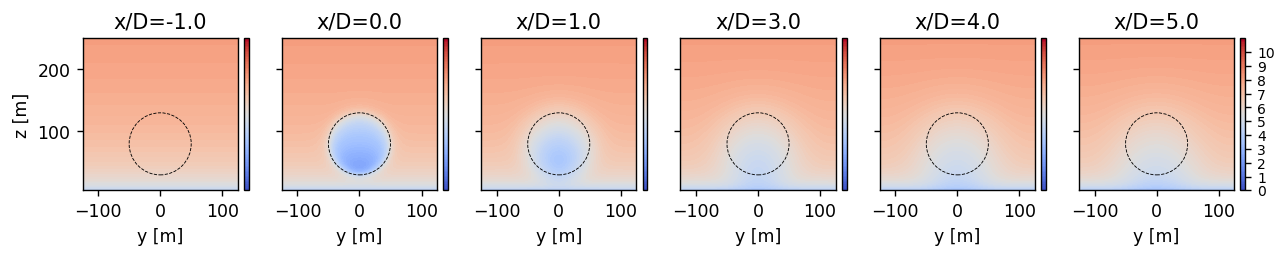

In [13]:
savefigs = False
cbarticks=np.arange(0,11,1)

fig, axs = plt.subplots(1, len(xvecplot), figsize=(12,3.25), dpi=125, sharey=True)
for ix, x in enumerate(xvecplot):
    ixRANS = find_nearest(xvec, x)
    c=axs[ix].contourf(ym, zm, phi['u'][ixRANS,:,:], levels=np.linspace(0,11,91), cmap='coolwarm')
    #c=axs[ix].contourf(ym, zm, phi['v'][ixRANS,:,:], levels=np.linspace(-2,2,91), cmap='coolwarm')
    axs[ix].set_aspect('equal')
    axs[ix].set_title('x/D=%.1f'%(0.5*x/turbR))
    axs[ix].set_xlabel('y [m]')
    rotorcirc = plt.Circle((0.0, turbhh), turbR, color='k', linestyle='--', lw=0.5, fill=False)
    axs[ix].add_patch(rotorcirc)
    
    divider = make_axes_locatable(axs[ix])
    cax = divider.append_axes("right", size="3%", pad=0.05)
    if ix < len(xvecplot)-1:
        cbar=fig.colorbar(c, ax=axs[ix], cax=cax, ticks = matplotlib.ticker.FixedLocator([]))
    else:
        cbar=fig.colorbar(c, ax=axs[ix], cax=cax,ticks = matplotlib.ticker.FixedLocator(cbarticks))
        cbar.ax.tick_params(labelsize=8)
        
axs[0].set_ylabel('z [m]')

if savefigs:
    plt.tight_layout()
    plt.savefig('TestABL_KEPST.png')

Text(0, 0.5, 'z [m]')

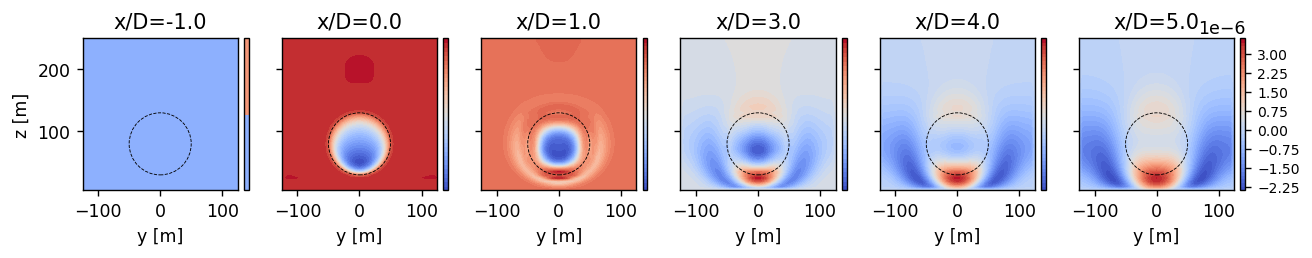

In [14]:
savefigs = False
#cbarticks=np.linspace(-0.001,0.001,5)
clevels=41 #np.linspace(-0.001,0.001,41)

fig, axs = plt.subplots(1, len(xvecplot), figsize=(12,3.25), dpi=125, sharey=True)
for ix, x in enumerate(xvecplot):
    ixRANS = find_nearest(xvec, x)
    c=axs[ix].contourf(ym, zm, phi['p'][ixRANS,:,:], levels=clevels, cmap='coolwarm')
    #c=axs[ix].contourf(ym, zm, phi['v'][ixRANS,:,:], levels=np.linspace(-2,2,91), cmap='coolwarm')
    axs[ix].set_aspect('equal')
    axs[ix].set_title('x/D=%.1f'%(0.5*x/turbR))
    axs[ix].set_xlabel('y [m]')
    rotorcirc = plt.Circle((0.0, turbhh), turbR, color='k', linestyle='--', lw=0.5, fill=False)
    axs[ix].add_patch(rotorcirc)
    
    divider = make_axes_locatable(axs[ix])
    cax = divider.append_axes("right", size="3%", pad=0.05)
    if ix < len(xvecplot)-1:
        cbar=fig.colorbar(c, ax=axs[ix], cax=cax, ticks = matplotlib.ticker.FixedLocator([]))
    else:
        cbar=fig.colorbar(c, ax=axs[ix], cax=cax, )#ticks = matplotlib.ticker.FixedLocator(cbarticks))
        #cbar=fig.colorbar(c, ax=axs[ix], cax=cax)
        cbar.ax.tick_params(labelsize=8)
        
axs[0].set_ylabel('z [m]')
